In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models  
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

In [3]:
def plot_curves(file_paths, save_dir='./Image'):
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)

    # 读取数据
    data = {}
    for file_path in file_paths:
        model_name = os.path.basename(file_path).split('_')[0]
        df = pd.read_csv(file_path)
        data[model_name] = df

    # 绘制损失曲线
    plt.figure(figsize=(12, 6))
    for model_name, df in data.items():
        plt.plot(df['epoch'], df['train_losses'], label=f'{model_name} Train Loss')
        plt.plot(df['epoch'], df['val_losses'], label=f'{model_name} val Loss', linestyle='--')
    plt.title('Training and valing Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'loss_curves.png'))
    plt.show()
    plt.close()

    # 绘制准确率曲线
    plt.figure(figsize=(12, 6))
    for model_name, df in data.items():
        plt.plot(df['epoch'], df['train_accuracies'], label=f'{model_name} Train Accuracy')
        plt.plot(df['epoch'], df['val_accuracies'], label=f'{model_name} val Accuracy', linestyle='--')
    plt.title('Training and valing Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'accuracy_curves.png'))
    plt.show()
    plt.close()

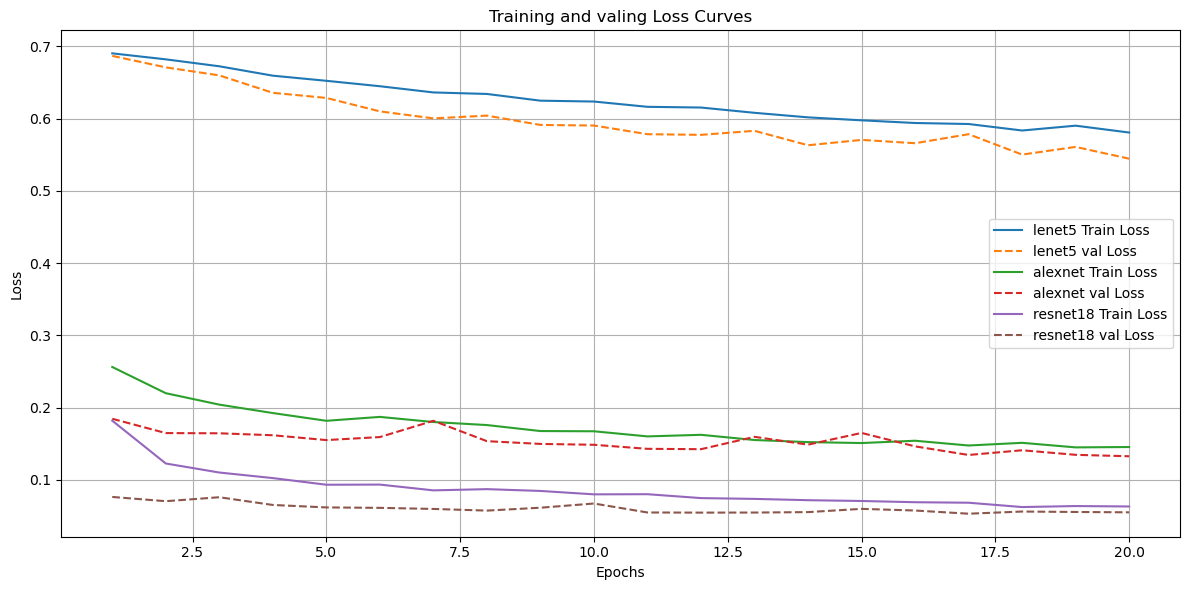

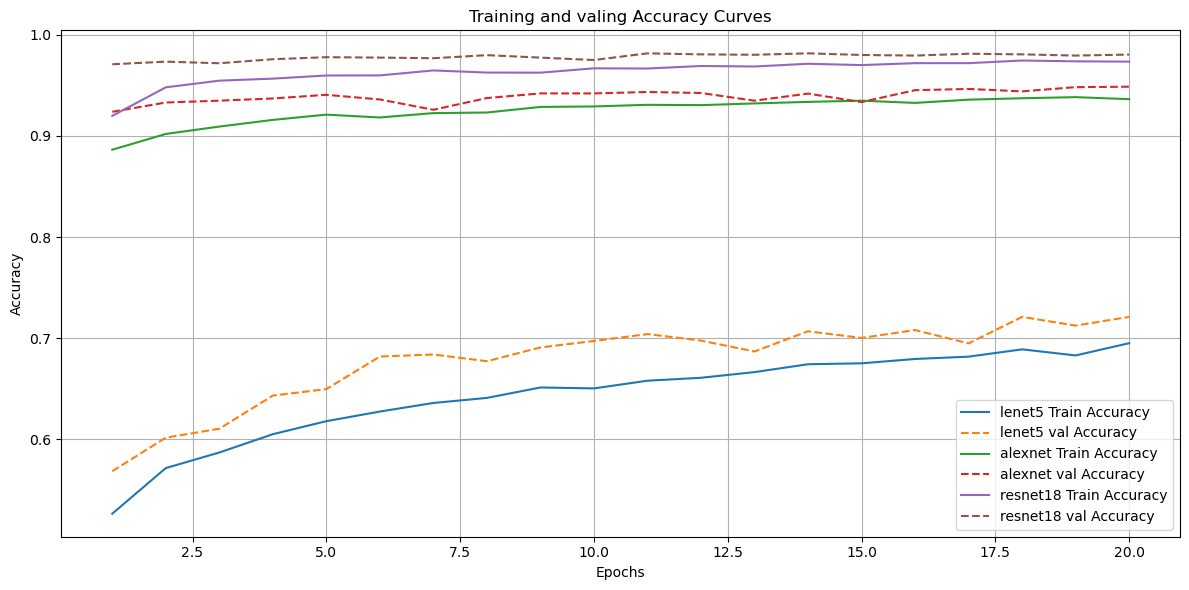

In [5]:
file_paths = [
    './training_results/lenet5_training_results.txt',
    './training_results/alexnet_training_results.txt',
    './training_results/resnet18_training_results.txt'
]
plot_curves(file_paths)

In [7]:
# LeNet5模型
class LeNet5(nn.Module):
    def __init__(self, num_classes=2):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),  # 输入通道3，输出通道6，卷积核大小5
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 池化大小2，步长2
            nn.Conv2d(6, 16, kernel_size=5),  # 输入通道6，输出通道16，卷积核大小5
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)  # 池化大小2，步长2
        )
        # 手动计算特征图尺寸 (148-4)/2 -> (72-4)/2 = 34
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 34 * 34, 120),  # 16是通道数，34是特征图大小
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [9]:
def evaluate_model(model, dataloader, device, criterion, model_name):
    """
    评估给定的神经网络模型在验证集上的性能。

    参数:
        model (torch.nn.Module): 要评估的模型。
        dataloader: 验证数据加载器。
        device: 运算设备（例如GPU或CPU）。
        criterion: 损失函数。
        model_name (str): 模型名称，用于输出信息。

    返回值:
        all_labels (list): 所有真实标签的列表。
        all_preds (list): 所有预测标签的列表。
        val_loss (float): 平均验证损失。
        val_acc (float): 验证准确率。
    """

    model.eval()  # 设置模型为评估模式

    val_loss = 0.0  # 初始化验证损失为0
    correct = 0  # 初始化正确预测的数量为0
    total = 0  # 初始化总样本数量为0
    all_labels = []  # 保存所有真实标签
    all_preds = []  # 保存所有预测标签
    
    # 使用tqdm显示进度条
    with tqdm(total=len(dataloader), desc=f'Evaluating {model_name}', unit='batch') as pbar:
        with torch.no_grad(): 
            for images, labels in dataloader:
                images, labels = images.to(device), labels.to(device)  # 将输入和标签移动到指定设备
                
                outputs = model(images)  # 前向传播得到模型输出
                loss = criterion(outputs, labels)  # 计算损失
                
                val_loss += loss.item()  # 累加损失值
                _, predicted = torch.max(outputs.data, 1)  # 获取每个样本的最大值对应的索引作为预测结果
                total += labels.size(0)  # 累加总样本数
                correct += (predicted == labels).sum().item()  # 统计正确预测的数量
                all_labels.extend(labels.cpu().numpy())  # 收集真实标签
                all_preds.extend(predicted.cpu().numpy())  # 收集预测标签
                
                # 更新进度条信息，包括平均损失和准确率
                pbar.set_postfix({
                    'val Loss': val_loss / (pbar.n + 1),
                    'val Acc': correct / total
                })
                pbar.update(1)  # 更新进度条

    # 计算平均验证损失和准确率
    val_loss = val_loss / len(dataloader)
    val_acc = correct / total
    
    # 输出验证损失和准确率
    print(f'{model_name} val Loss: {val_loss:.4f}, val Acc: {val_acc:.4f}')
    
    return all_labels, all_preds, val_loss, val_acc  # 返回收集的真实标签、预测标签、平均损失和准确率

In [11]:
def save_confusion_matrix(cm, class_names, model_name):
    """
    生成并保存给定模型的混淆矩阵图像。

    参数:
        cm (numpy.ndarray): 混淆矩阵，由sklearn.metrics.confusion_matrix计算得出。
        class_names (list of str): 类别名称列表，用于标记混淆矩阵的轴。
        model_name (str): 模型名称，用于文件命名和图标题。

    返回值:
        None: 该函数不返回任何值，但会保存一个PNG格式的混淆矩阵图像，并显示它。
    """

    # 创建一个新的图形窗口，指定大小为10x7英寸
    plt.figure(figsize=(10, 7))
    
    # 使用seaborn库绘制热力图表示混淆矩阵
    # annot=True 表示在每个单元格中添加数据标签
    # fmt='d' 表示以整数格式显示数字
    # cmap='YlOrRd' 设置颜色映射（从浅黄色到深红色）
    # xticklabels 和 yticklabels 分别设置X轴和Y轴的标签
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_names, yticklabels=class_names)
    
    # 设置X轴标签为“Predicted”
    plt.xlabel('Predicted')
    
    # 设置Y轴标签为“True”
    plt.ylabel('True')
    
    # 设置图表标题，包含模型名称
    plt.title(f'Confusion Matrix for {model_name}')
    
    # 保存混淆矩阵图像到指定路径，确保目录存在
    os.makedirs('./Image', exist_ok=True)  # 如果目录不存在则创建
    plt.savefig(f'./Image/{model_name}_confusion_matrix.png')  # 保存图像
    
    # 显示图像
    plt.show()
    
    # 关闭当前图形，释放内存
    plt.close()

In [13]:
def main():
    # 训练集和验证集路径
    train_path = './data/train'
    val_path = './data/validation'

    # 获取训练集和验证集的标签
    train_labels = sorted(os.listdir(train_path))
    val_labels = sorted(os.listdir(val_path))
    if train_labels == val_labels:
        animal_labels = train_labels = val_labels
    print("animal_labels: ", animal_labels)

    # 数据预处理
    val_transform = transforms.Compose([
        transforms.Resize((148, 148)),  
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    # 加载数据集
    val_dataset = ImageFolder(val_path, transform=val_transform)
    batch_size = 64
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 定义设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 定义损失函数
    criterion = nn.CrossEntropyLoss()

    # 评估 LeNet5 模型
    lenet5_model = LeNet5(num_classes=len(animal_labels))
    lenet5_model.load_state_dict(torch.load('./weights/lenet5_best_model.pth', map_location=device, weights_only=False))
    lenet5_model = lenet5_model.to(device)
    lenet5_labels, lenet5_preds, lenet5_loss, lenet5_acc = evaluate_model(lenet5_model, val_loader, device, criterion, 'LeNet5')

    # 评估 AlexNet 模型
    alexnet_model = models.alexnet(weights=None)
    num_features = alexnet_model.classifier[6].in_features
    alexnet_model.classifier[6] = nn.Linear(num_features, len(animal_labels))  # 修改最后一层
    alexnet_model.load_state_dict(torch.load('./weights/alexnet_best_model.pth', map_location=device, weights_only=False))
    alexnet_model = alexnet_model.to(device)
    alexnet_labels, alexnet_preds, alexnet_loss, alexnet_acc = evaluate_model(alexnet_model, val_loader, device, criterion, 'AlexNet')

    # 评估 ResNet18 模型
    resnet18_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_features = resnet18_model.fc.in_features
    resnet18_model.fc = nn.Linear(num_features, len(animal_labels))
    resnet18_model.load_state_dict(torch.load('./weights/resnet18_best_model.pth', map_location=device, weights_only=False))
    resnet18_model = resnet18_model.to(device)
    resnet18_labels, resnet18_preds, resnet18_loss, resnet18_acc = evaluate_model(resnet18_model, val_loader, device, criterion, 'ResnNet18')
    
    # 创建保存目录
    os.makedirs('./training_results', exist_ok=True)
    os.makedirs('./Image', exist_ok=True)

    # 保存分类报告
    with open('./training_results/classification_reports.txt', 'w') as f:
        f.write('Classification Report for LeNet5:\n')
        report_lenet5 = classification_report(lenet5_labels, lenet5_preds, target_names=animal_labels)
        f.write(report_lenet5)
        print(f'Classification Report for LeNet5:\n{report_lenet5}\n')
        f.write('\n\n')
        
        f.write('Classification Report for AlexNet:\n')
        report_alexnet = classification_report(alexnet_labels, alexnet_preds, target_names=animal_labels)
        f.write(report_alexnet)
        print(f'Classification Report for AlexNet:\n{report_alexnet}\n')
        f.write('\n\n')

        f.write('Classification Report for ResNet18:\n')
        report_resnet18 = classification_report(resnet18_labels, resnet18_preds, target_names=animal_labels)
        f.write(report_resnet18)
        print(f'Classification Report for ResNet18:\n{report_resnet18}\n')
        f.write('\n\n')

    # 绘制并保存混淆矩阵
    cm_lenet5 = confusion_matrix(lenet5_labels, lenet5_preds)
    save_confusion_matrix(cm_lenet5, animal_labels, 'LeNet5')

    cm_alexnet = confusion_matrix(alexnet_labels, alexnet_preds)
    save_confusion_matrix(cm_alexnet, animal_labels, 'AlexNet')

    cm_resnet18 = confusion_matrix(resnet18_labels, resnet18_preds)
    save_confusion_matrix(cm_resnet18, animal_labels, 'ResNet18')

animal_labels:  ['cats', 'dogs']


Evaluating LeNet5: 100%|█████████████████████████████| 79/79 [01:35<00:00,  1.21s/batch, val Loss=0.549, val Acc=0.721]


LeNet5 val Loss: 0.5489, val Acc: 0.7210


Evaluating AlexNet: 100%|████████████████████████████| 79/79 [01:32<00:00,  1.17s/batch, val Loss=0.134, val Acc=0.949]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\14942/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


AlexNet val Loss: 0.1338, val Acc: 0.9488


100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [02:58<00:00, 263kB/s]
Evaluating ResnNet18: 100%|█████████████████████████| 79/79 [02:49<00:00,  2.14s/batch, val Loss=0.0548, val Acc=0.981]


ResnNet18 val Loss: 0.0548, val Acc: 0.9814
Classification Report for LeNet5:
              precision    recall  f1-score   support

        cats       0.70      0.76      0.73      2500
        dogs       0.74      0.68      0.71      2500

    accuracy                           0.72      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.72      0.72      0.72      5000


Classification Report for AlexNet:
              precision    recall  f1-score   support

        cats       0.95      0.95      0.95      2500
        dogs       0.95      0.95      0.95      2500

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000


Classification Report for ResNet18:
              precision    recall  f1-score   support

        cats       0.98      0.98      0.98      2500
        dogs       0.98      0.98      0.98      2500

    accuracy                   

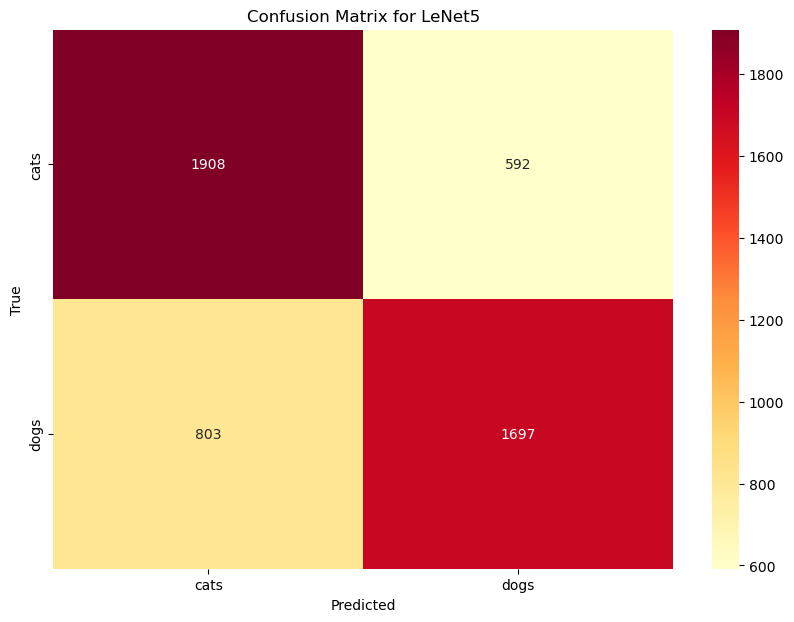

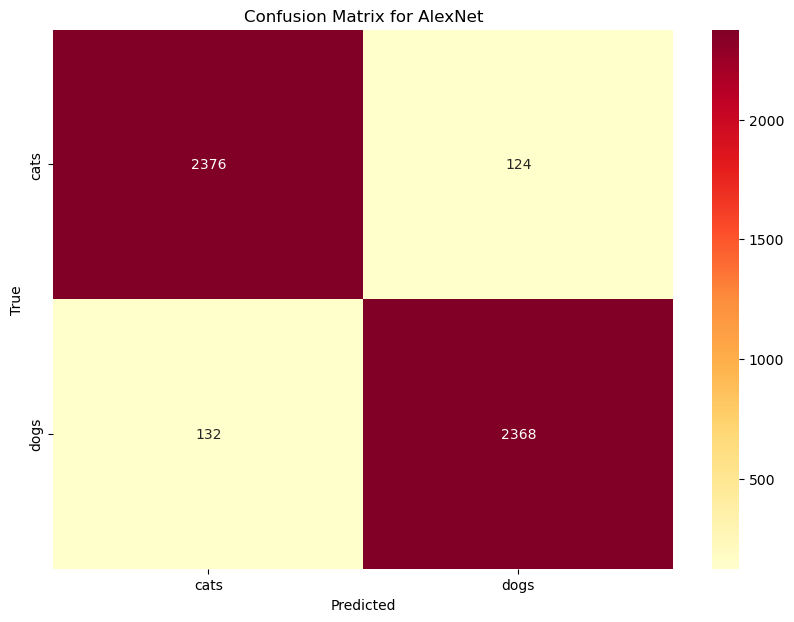

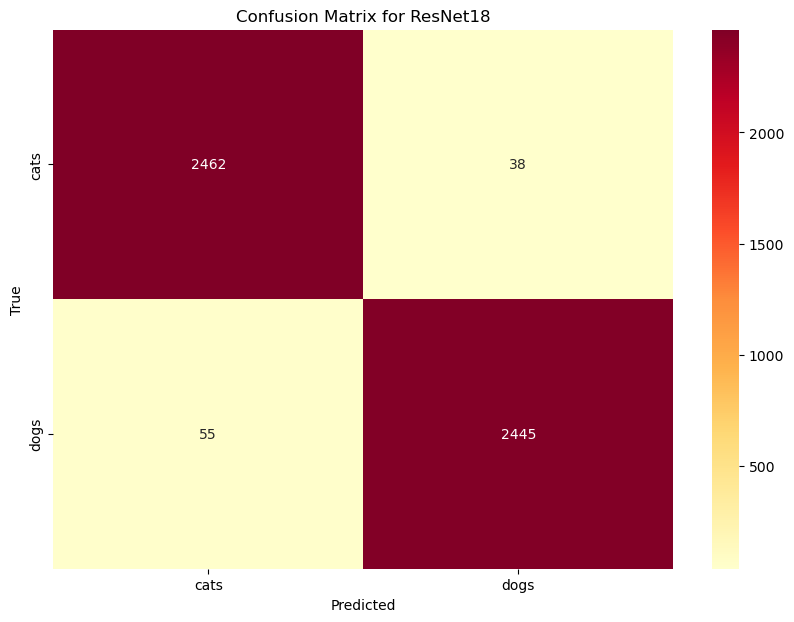

In [15]:
main()